In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use('ggplot')
sns.set_theme(font_scale=1.1)

In [4]:
df = pd.read_csv("Dataset .csv")

print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Rows    : 9551
Columns : 21

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating col


MISSING VALUE ANALYSIS
          Missing Values  Percentage (%)
Cuisines               9            0.09


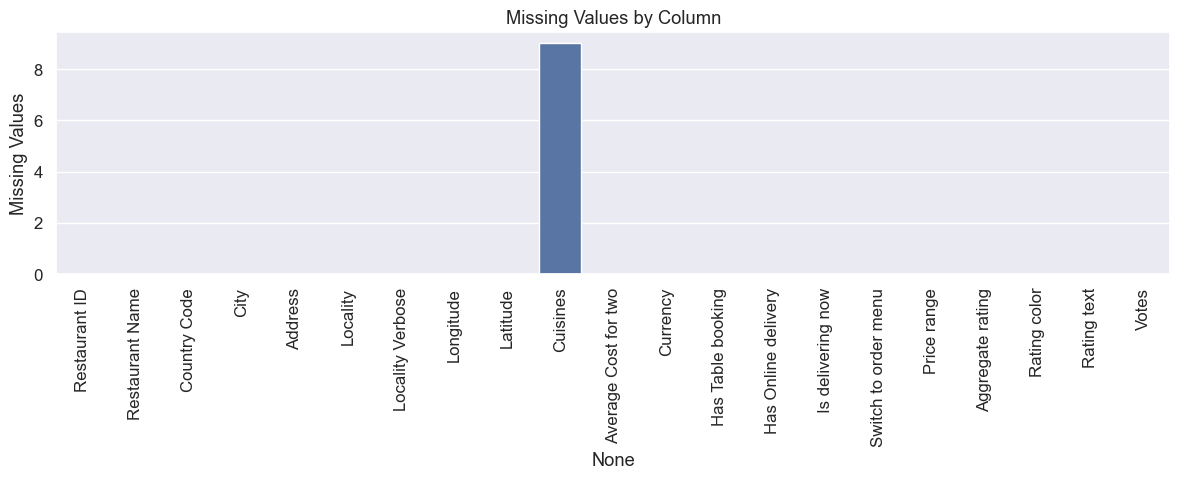

In [5]:
print("\n" + "="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": round((missing_values/len(df))*100,2)
})

print(missing_df[missing_df["Missing Values"] > 0])

plt.figure(figsize=(12,5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Values"]
)

plt.title("Missing Values by Column")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [6]:
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

num_cols = df.select_dtypes(include=np.number).columns

stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Std Dev": df[num_cols].std(),
    "Variance": df[num_cols].var(),
    "Min": df[num_cols].min(),
    "Max": df[num_cols].max(),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurt()
}).round(2)


DESCRIPTIVE STATISTICS



Generating Distribution Plots...


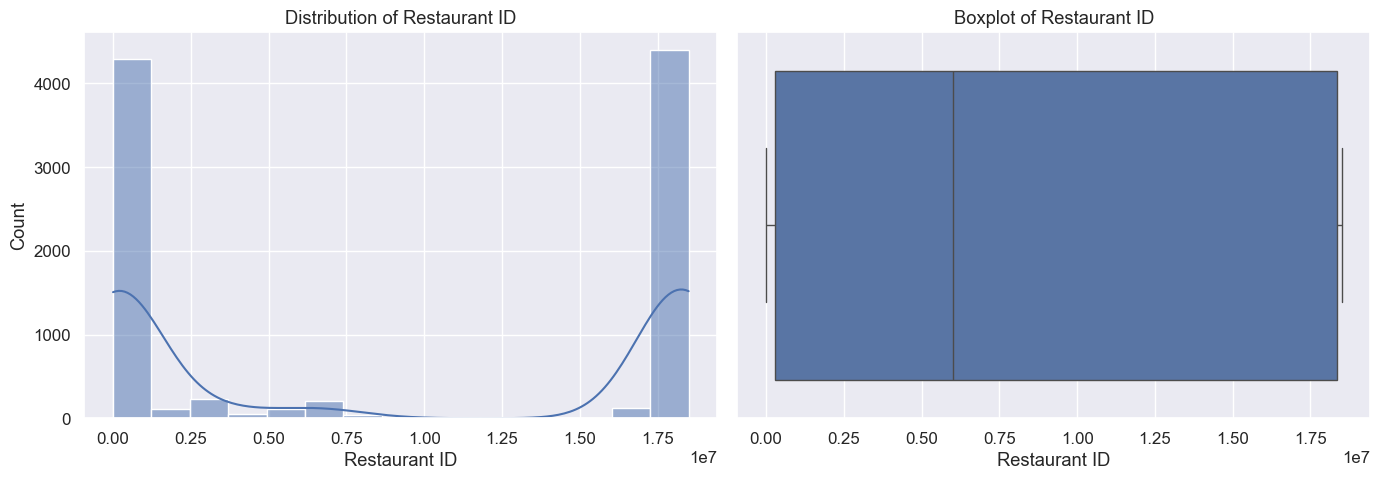

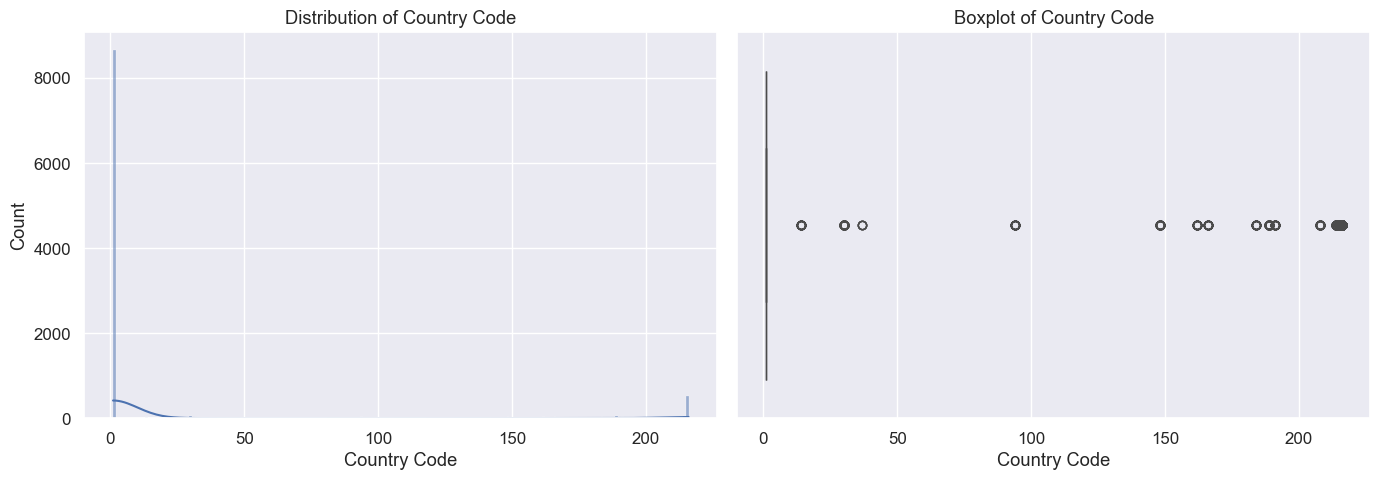

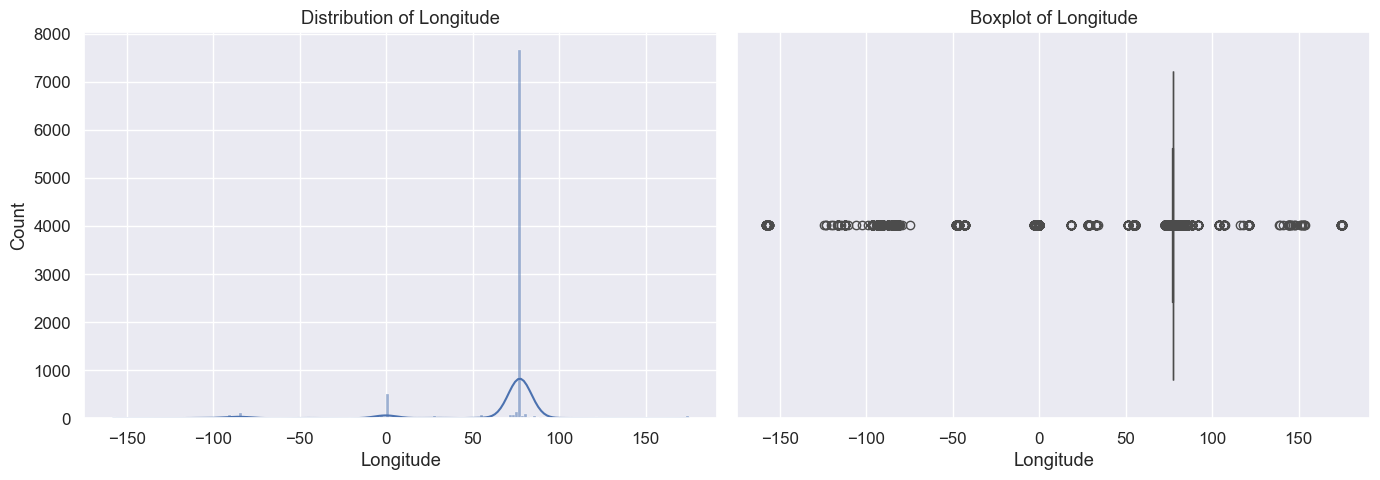

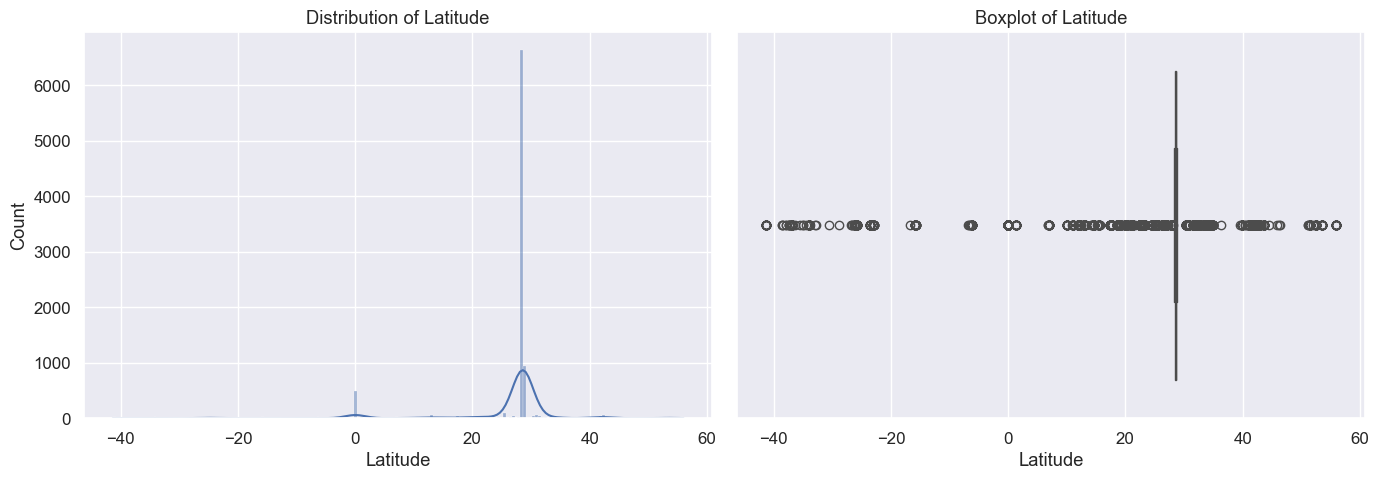

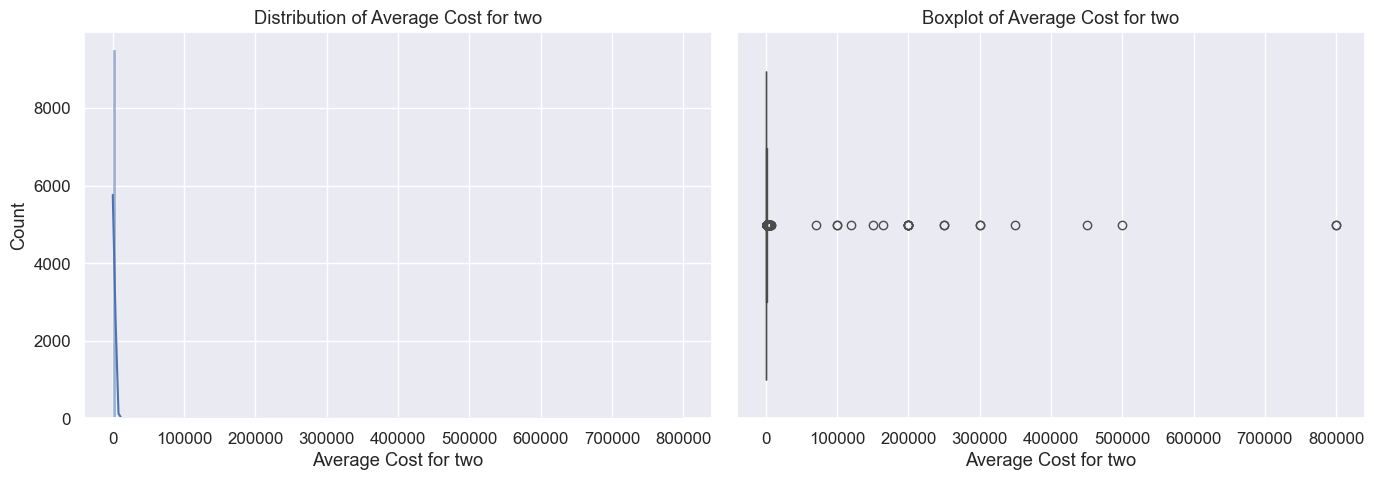

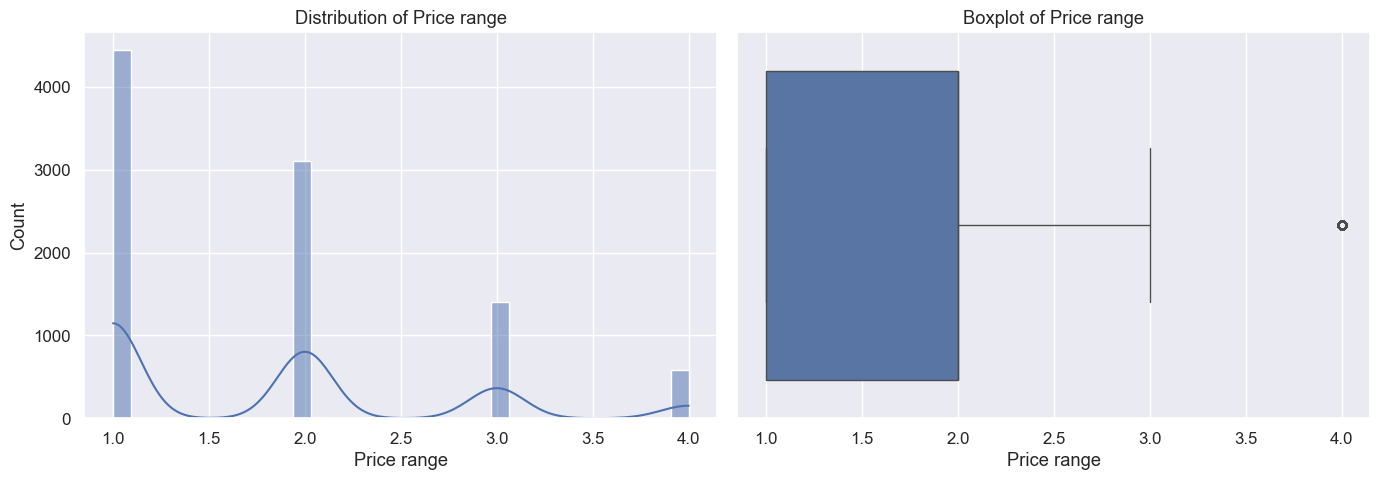

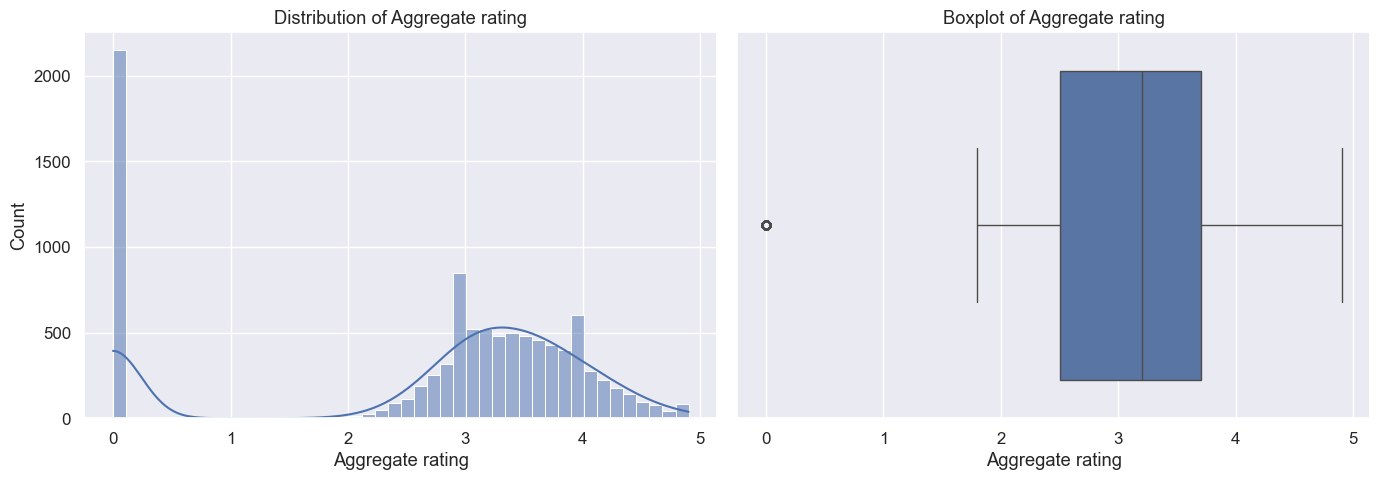

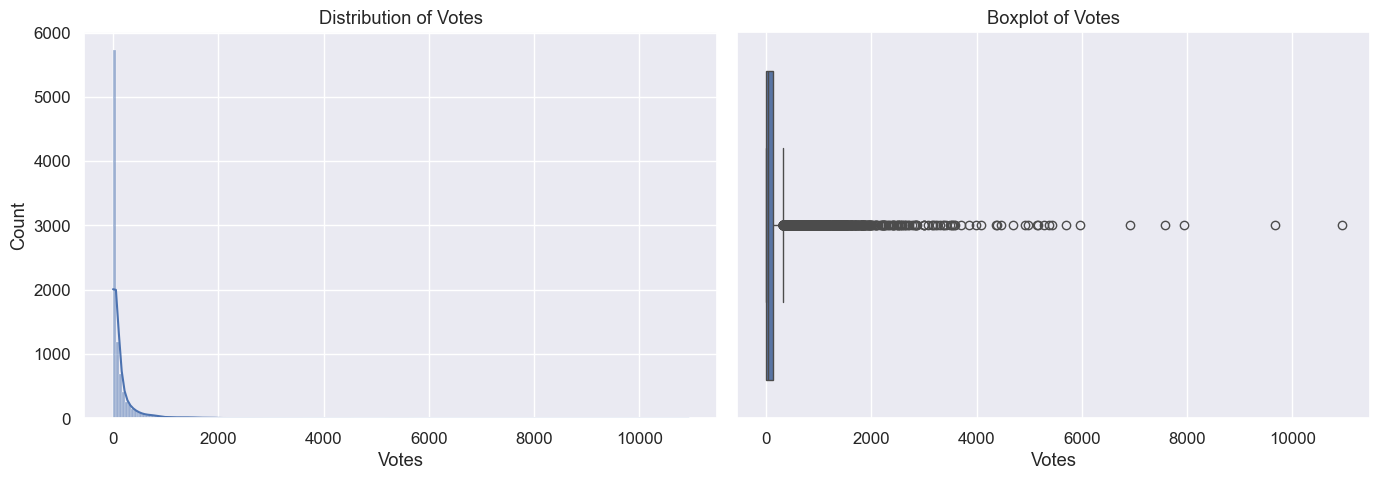

In [7]:
print("\nGenerating Distribution Plots...")

for col in num_cols:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14,5)
    )

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f'Distribution of {col}')

    sns.boxplot(
        x=df[col],
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


COUNTRY CODE ANALYSIS
              Restaurants  Percentage (%)
Country Code                             
1                    8652           90.59
216                   434            4.54
215                    80            0.84
30                     60            0.63
214                    60            0.63
189                    60            0.63
148                    40            0.42
208                    34            0.36
14                     24            0.25
162                    22            0.23
94                     21            0.22
184                    20            0.21
166                    20            0.21
191                    20            0.21
37                      4            0.04


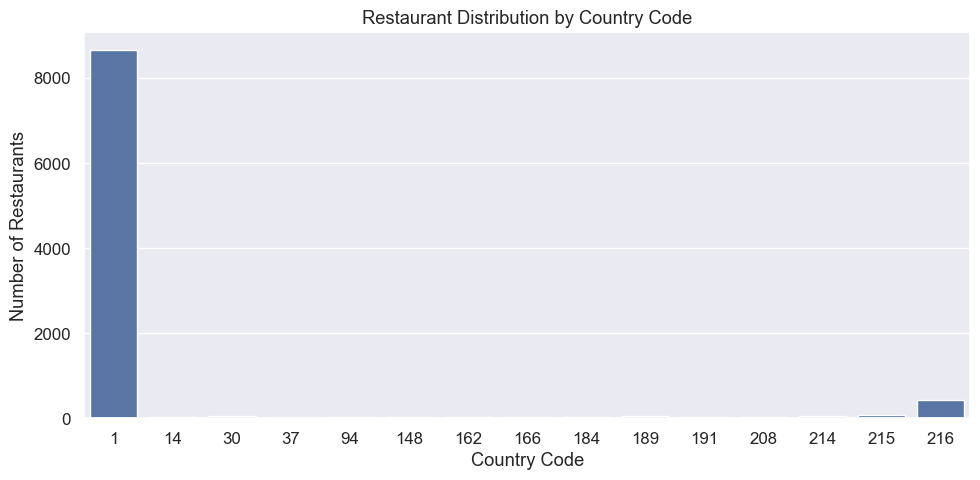

In [8]:
print("\n" + "="*80)
print("COUNTRY CODE ANALYSIS")
print("="*80)

country_counts = df['Country Code'].value_counts()

country_df = pd.DataFrame({
    "Restaurants": country_counts,
    "Percentage (%)": round(country_counts/len(df)*100,2)
})

print(country_df)

plt.figure(figsize=(10,5))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Restaurant Distribution by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()



CITY ANALYSIS

Top 15 Cities:
                Restaurants  Percentage (%)
City                                       
New Delhi              5473           57.30
Gurgaon                1118           11.71
Noida                  1080           11.31
Faridabad               251            2.63
Ghaziabad                25            0.26
Bhubaneshwar             21            0.22
Amritsar                 21            0.22
Ahmedabad                21            0.22
Lucknow                  21            0.22
Guwahati                 21            0.22
Ludhiana                 20            0.21
Rest of Hawaii           20            0.21
Kochi                    20            0.21
Kolkata                  20            0.21
Pocatello                20            0.21


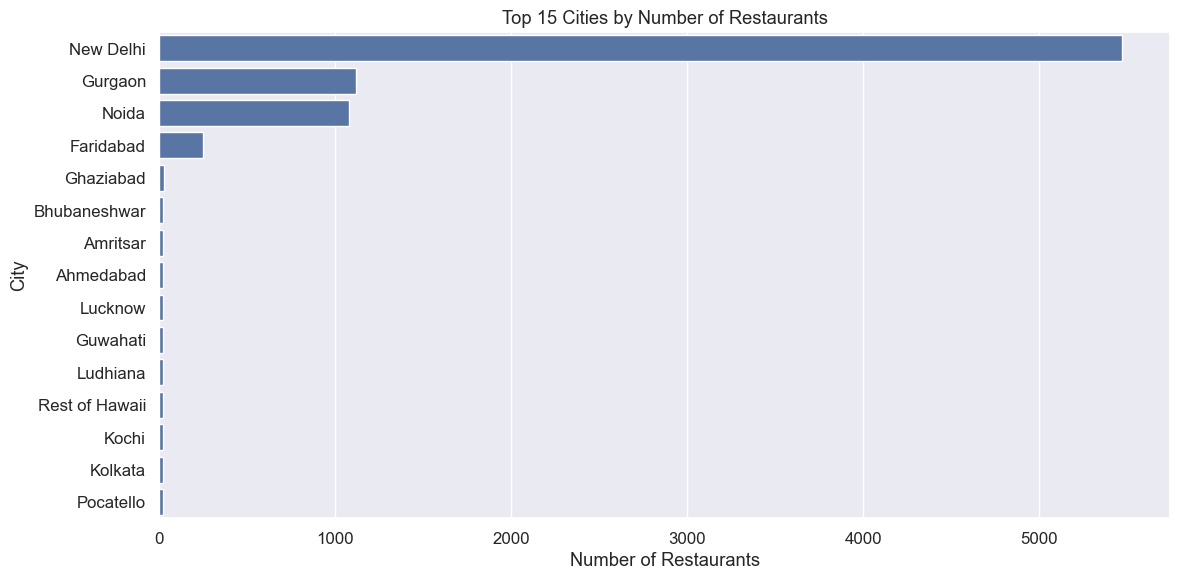

In [9]:
print("\n" + "="*80)
print("CITY ANALYSIS")
print("="*80)

city_counts = df['City'].value_counts()

city_df = pd.DataFrame({
    "Restaurants": city_counts,
    "Percentage (%)": round(city_counts/len(df)*100,2)
})

print("\nTop 15 Cities:")
print(city_df.head(15))

plt.figure(figsize=(12,6))

sns.barplot(
    x=city_counts.head(15).values,
    y=city_counts.head(15).index
)

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()



CUISINE ANALYSIS

Top 20 Cuisines:
              Restaurants  Percentage (%)
Cuisines                                 
North Indian         3960           20.09
Chinese              2735           13.88
Fast Food            1986           10.08
Mughlai               995            5.05
Italian               764            3.88
Bakery                745            3.78
Continental           736            3.73
Cafe                  703            3.57
Desserts              653            3.31
South Indian          636            3.23
Street Food           562            2.85
American              390            1.98
Pizza                 381            1.93
Mithai                380            1.93
Burger                251            1.27
Thai                  234            1.19
Asian                 233            1.18
Beverages             229            1.16
Ice Cream             226            1.15
Mexican               181            0.92


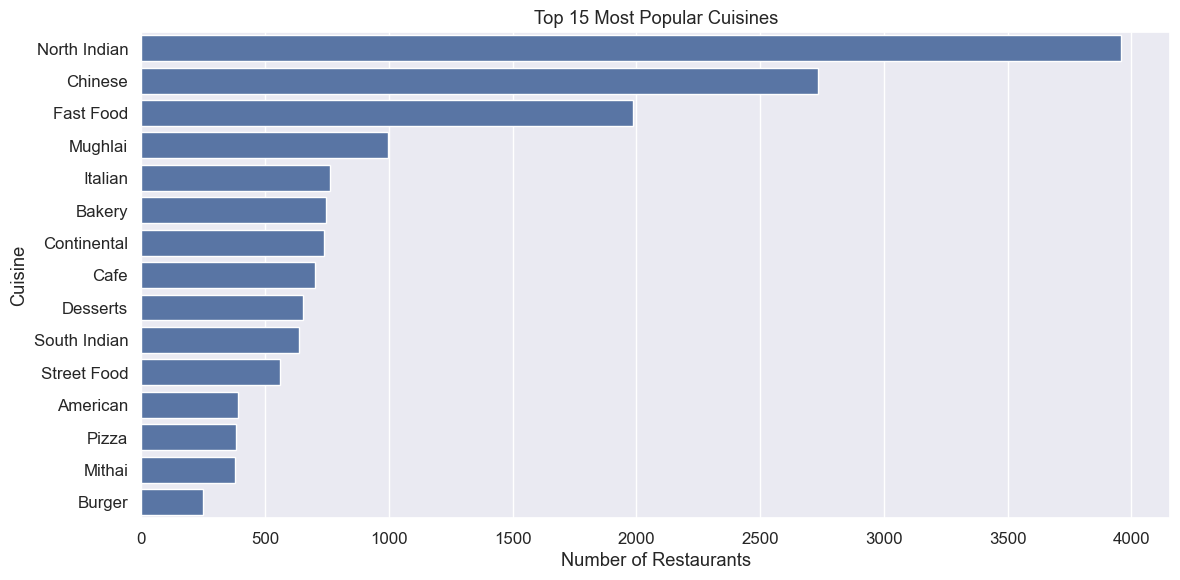

In [10]:
print("\n" + "="*80)
print("CUISINE ANALYSIS")
print("="*80)

cuisine_counts = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

cuisine_df = pd.DataFrame({
    "Restaurants": cuisine_counts,
    "Percentage (%)": round(cuisine_counts/cuisine_counts.sum()*100,2)
})

print("\nTop 20 Cuisines:")
print(cuisine_df.head(20))

plt.figure(figsize=(12,6))

sns.barplot(
    x=cuisine_counts.head(15).values,
    y=cuisine_counts.head(15).index
)

plt.title("Top 15 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()



CORRELATION ANALYSIS


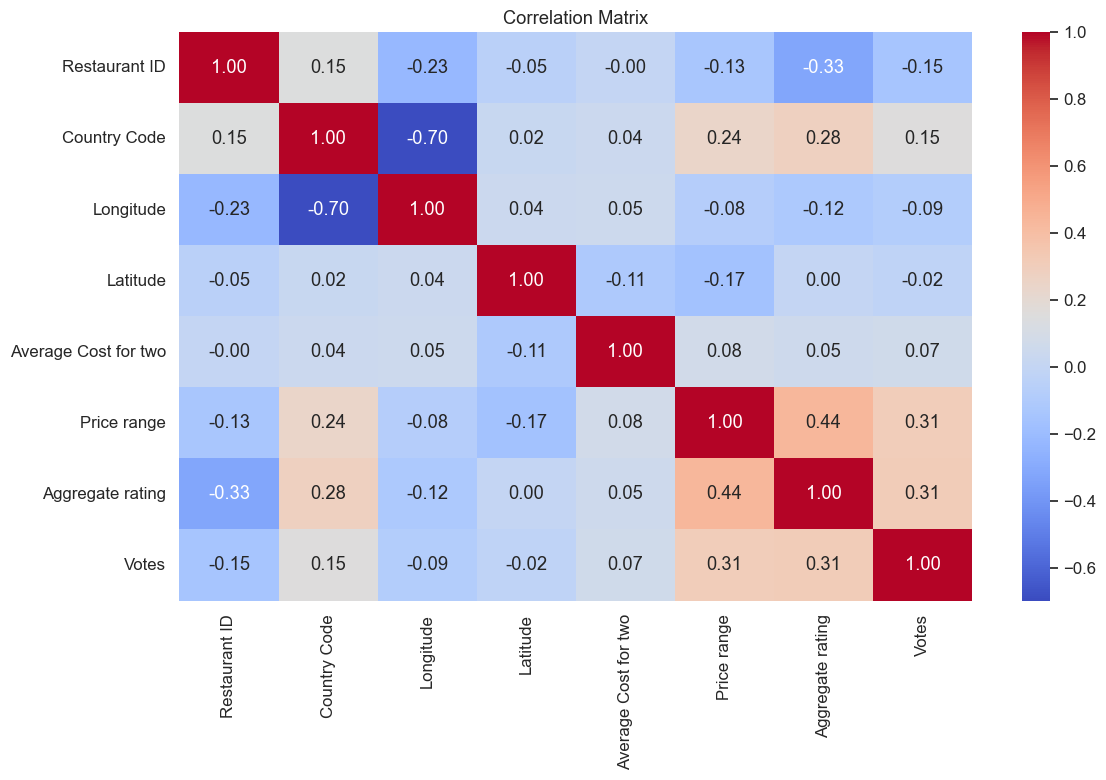

In [11]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [12]:
print("\n" + "="*80)
print("KEY BUSINESS INSIGHTS")
print("="*80)

print(f"""
1. Total Restaurants Analysed : {len(df):,}

2. Total Cities Covered       : {df['City'].nunique()}

3. Total Countries Covered    : {df['Country Code'].nunique()}

4. Most Popular City          : {city_counts.idxmax()}
   Restaurant Count           : {city_counts.max()}

5. Most Popular Cuisine       : {cuisine_counts.idxmax()}
   Restaurant Count           : {cuisine_counts.max()}

6. Average Rating             : {df['Aggregate rating'].mean():.2f}

7. Highest Rating             : {df['Aggregate rating'].max():.2f}

8. Average Cost For Two       : {df['Average Cost for two'].mean():.2f}

9. Median Cost For Two        : {df['Average Cost for two'].median():.2f}
""")

print("\nAnalysis Completed Successfully!")


KEY BUSINESS INSIGHTS

1. Total Restaurants Analysed : 9,551

2. Total Cities Covered       : 141

3. Total Countries Covered    : 15

4. Most Popular City          : New Delhi
   Restaurant Count           : 5473

5. Most Popular Cuisine       : North Indian
   Restaurant Count           : 3960

6. Average Rating             : 2.67

7. Highest Rating             : 4.90

8. Average Cost For Two       : 1199.21

9. Median Cost For Two        : 400.00


Analysis Completed Successfully!
